# Chapter 74 — Iterative Computation

> **Prerequisites:** ch052 (Functions as Programs), ch071 (Modeling)
>
> **You will learn:**
> - Apply fixed-point iteration to solve equations
> - Implement Newton-Raphson root finding
> - Understand convergence rates
> - Connect iteration to optimization algorithms
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

**Iterative computation** solves problems by repeatedly applying a function until a fixed condition is met (convergence).

**Fixed-point iteration:** xₙ₊₁ = g(xₙ). A fixed point x* satisfies x* = g(x*). The iteration converges to x* if |g'(x*)| < 1.

**Newton-Raphson method:** Find roots of f(x) = 0:
xₙ₊₁ = xₙ - f(xₙ)/f'(xₙ)

Geometric interpretation: follow the tangent line to its x-intercept, then repeat. Converges quadratically when near a root.

**Convergence rate:**
- Linear convergence: |eₙ₊₁| ≈ C·|eₙ| — error shrinks by constant factor
- Quadratic convergence: |eₙ₊₁| ≈ C·|eₙ|² — error squares each step (very fast near solution)

**Applications in ML:**
- Gradient descent is iterative: θₙ₊₁ = θₙ - α·∇L(θₙ)
- EM algorithm, power iteration for eigenvectors, Jacobi method for linear systems

---

## 2. Intuition & Mental Models

**Physical analogy:** Tuning a guitar. You pluck, listen, tighten or loosen, repeat. Each iteration brings you closer to the target pitch. Fast convergence = few iterations to tune. Slow convergence = many fine adjustments.

**Computational analogy:** Binary search is iterative with linear convergence (halves the interval each step). Newton's method is iterative with quadratic convergence — it squares its accuracy each step. For a 1e-10 error target, binary search needs ~33 iterations; Newton's needs ~4.

---

## 3. Visualization

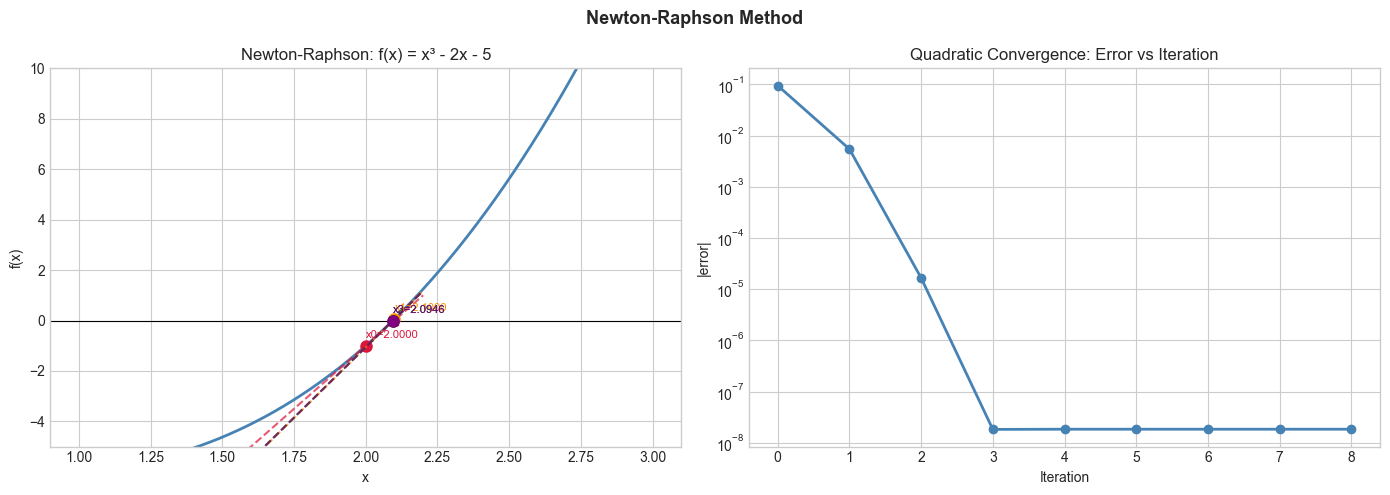

In [1]:
# --- Visualization: Newton-Raphson convergence ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def f(x): return x**3 - 2*x - 5
def df(x): return 3*x**2 - 2

x_fine = np.linspace(1, 3, 500)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Show Newton iterations
ax = axes[0]
ax.plot(x_fine, f(x_fine), color='steelblue', linewidth=2)
ax.axhline(0, color='black', linewidth=0.8)
colors = ['crimson', 'darkorange', 'darkgreen', 'purple']
x_curr = 2.0  # initial guess
for i, color in enumerate(colors):
    y_curr = f(x_curr)
    slope = df(x_curr)
    x_next = x_curr - y_curr / slope
    x_tang = np.linspace(x_curr - 0.5, x_next + 0.1, 100)
    ax.plot(x_tang, y_curr + slope*(x_tang - x_curr), color=color, linestyle='--', linewidth=1.5, alpha=0.7)
    ax.plot(x_curr, y_curr, 'o', color=color, markersize=8)
    ax.plot(x_next, 0, 's', color=color, markersize=6)
    ax.annotate(f'x{i}={x_curr:.4f}', (x_curr, y_curr + 0.3), fontsize=8, color=color)
    x_curr = x_next
ax.set_title("Newton-Raphson: f(x) = x³ - 2x - 5"); ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_ylim(-5, 10)

# Error convergence
ax = axes[1]
x_true = 2.0945515  # true root
x_curr = 2.0
errors = [abs(x_curr - x_true)]
for _ in range(8):
    x_curr = x_curr - f(x_curr)/df(x_curr)
    errors.append(abs(x_curr - x_true))
ax.semilogy(errors, 'o-', color='steelblue', linewidth=2)
ax.set_title('Quadratic Convergence: Error vs Iteration'); ax.set_xlabel('Iteration'); ax.set_ylabel('|error|')

plt.suptitle('Newton-Raphson Method', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 5. Python Implementation

In [2]:
# --- Implementation: Iterative methods toolkit ---
import numpy as np

def newton_raphson(f, df, x0, tol=1e-10, max_iter=100):
    """
    Newton-Raphson root finding: xₙ₊₁ = xₙ - f(xₙ)/f'(xₙ).
    
    Args:
        f: callable, function whose root is sought
        df: callable, derivative of f
        x0: float, initial guess
        tol: float, convergence tolerance
        max_iter: int
    Returns:
        x: float, approximate root
        history: list of iterate values
    """
    x = x0
    history = [x]
    for _ in range(max_iter):
        fx = f(x)
        if abs(fx) < tol:
            break
        dfx = df(x)
        if abs(dfx) < 1e-14:
            raise ValueError("Zero derivative — Newton's method failed")
        x = x - fx / dfx
        history.append(x)
    return x, history

def bisection(f, a, b, tol=1e-10, max_iter=100):
    """Bisection method: linear convergence, always works if f(a)*f(b)<0."""
    assert f(a) * f(b) < 0, "f(a) and f(b) must have opposite signs"
    history = []
    for _ in range(max_iter):
        mid = (a + b) / 2
        history.append(mid)
        if abs(b - a) < tol:
            break
        if f(mid) * f(a) < 0:
            b = mid
        else:
            a = mid
    return mid, history

# Compare on f(x) = x³ - 2x - 5
f = lambda x: x**3 - 2*x - 5
df = lambda x: 3*x**2 - 2

root_n, hist_n = newton_raphson(f, df, x0=2.0)
root_b, hist_b = bisection(f, 2.0, 3.0)

print(f"Newton root: {root_n:.10f} in {len(hist_n)} iterations")
print(f"Bisection root: {root_b:.10f} in {len(hist_b)} iterations")
print(f"True root: 2.0945514815423374")

Newton root: 2.0945514815 in 5 iterations
Bisection root: 2.0945514816 in 35 iterations
True root: 2.0945514815423374


---

## 6. Experiments

**Experiment 1:** Try Newton's method starting at x=0 for f(x) = x³ - 2x - 5. What happens? (The method may diverge or find a different root depending on starting point.)

**Experiment 2:** Implement fixed-point iteration for √2: xₙ₊₁ = (xₙ + 2/xₙ)/2 (Babylonian method). Count iterations to 10-digit accuracy. Compare to Newton's method.

---

## 7. Exercises

**Easy 1.** Use Newton's method to find √5 by solving f(x) = x² - 5 = 0. Start at x=2. How many iterations to 6 decimal place accuracy?

**Easy 2.** What is the fixed point of g(x) = cos(x)? Find it by iterating x₀ = 1, xₙ₊₁ = cos(xₙ) until convergence.

**Medium 1.** Implement Newton's method with numerical derivative (finite difference) instead of analytical df. Compare convergence.

**Medium 2.** Implement gradient descent on f(x) = x⁴ - 3x² + x with various step sizes α. Show that too large α causes divergence and too small causes slow convergence.

**Hard.** Implement the secant method: xₙ₊₁ = xₙ - f(xₙ)·(xₙ - xₙ₋₁)/(f(xₙ) - f(xₙ₋₁)). It approximates Newton's without needing f'. Prove its convergence order is the golden ratio φ ≈ 1.618. Compare convergence to Newton's and bisection empirically.

---

## 9. Chapter Summary & Connections

- Fixed-point iteration: xₙ₊₁ = g(xₙ); converges if |g'(x*)| < 1
- Newton-Raphson: quadratic convergence near root; requires derivative
- Bisection: linear convergence; always works; no derivative needed
- All of gradient descent, EM, power iteration are iterative methods

**Forward connections:**
- Gradient descent (ch212) is exactly iterative computation applied to minimization
- Power iteration for eigenvectors (ch173) is fixed-point iteration on matrices
- Newton's method reappears in second-order optimization (ch226)